<a href="https://colab.research.google.com/github/Reena0833/Ai_Music-/blob/main/%D8%A7%D9%84%D9%83%D9%88%D8%AF_%D8%A8%D8%B9%D8%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import gradio as gr

# ============================================
# تحميل البيانات
# ============================================
print("📂 جاري تحميل البيانات...")

try:
    df = pd.read_csv('/content/dataset 4444.csv')
    print(f"✅ تم تحميل {len(df)} أغنية بنجاح!")

except Exception as e:
    print(f"❌ فشل تحميل البيانات: {e}")
    df = None

# ============================================
# دوال البحث
# ============================================
def search_songs(query):

    if df is None:
        return "⚠️ البيانات غير محملة"

    if not query or query.strip() == "":
        return "📝 اكتب كلمة للبحث..."

    query = query.lower().strip()
    results = []

    # البحث في اسم الأغنية
    songs = df[df['track_name'].str.lower().str.contains(query, na=False)]

    for _, row in songs.head(5).iterrows():
        results.append(f"🎵 {row['track_name']} - {row['artists']}")

    # البحث في اسم الفنان
    artists = df[df['artists'].str.lower().str.contains(query, na=False)]

    for _, row in artists.head(5).iterrows():
        result = f"🎤 {row['track_name']} - {row['artists']}"

        if result not in results:
            results.append(result)

    if results:
        return "\n\n".join(results)

    return f"😕 لا توجد نتائج لـ '{query}'"


def get_top_songs(n=5):

    if df is None:
        return "⚠️ البيانات غير محملة"

    if 'popularity' in df.columns:

        top = df.nlargest(n, 'popularity')

        results = []

        for _, row in top.iterrows():
            results.append(
                f"🏆 {row['track_name']} - {row['artists']}\n   شعبية: {row['popularity']}"
            )

        return "\n\n".join(results)

    return "⚠️ لا يوجد عمود popularity"


def get_stats():

    if df is None:
        return "⚠️ البيانات غير محملة"

    stats = f"""📊 إحصائيات المكتبة الموسيقية

• عدد الأغاني: {len(df):,}
• عدد الفنانين: {df['artists'].nunique():,}
"""

    if 'track_genre' in df.columns:
        stats += f"• عدد الأنواع: {df['track_genre'].nunique()}\n"

    if 'popularity' in df.columns:
        stats += f"• متوسط الشعبية: {df['popularity'].mean():.1f}"

    return stats


def get_genres():

    if df is None:
        return "⚠️ البيانات غير محملة"

    if 'track_genre' in df.columns:

        genres = df['track_genre'].value_counts().head(10)

        result = "🎸 أشهر 10 أنواع موسيقية:\n\n"

        for genre, count in genres.items():
            result += f"• {genre}: {count} أغنية\n"

        return result

    return "⚠️ لا يوجد عمود أنواع"


# ============================================
# الواجهة الرسومية
# ============================================
with gr.Blocks(title="🎵 بوت الموسيقى") as demo:

    gr.Markdown("""
    # 🎵 بوت الموسيقى البسيط
    ### اكتشف الأغاني من قاعدة بيانات Spotify
    """)

    with gr.Row():

        with gr.Column(scale=2):

            search_input = gr.Textbox(
                label="🔍 ابحث عن أغنية أو فنان",
                placeholder="اكتب اسم الأغنية أو الفنان..."
            )

            search_btn = gr.Button("🔎 بحث")

        with gr.Column(scale=1):

            gr.Markdown("### 📌 أوامر سريعة")

            top_btn = gr.Button("🏆 أشهر الأغاني")
            stats_btn = gr.Button("📊 إحصائيات")
            genres_btn = gr.Button("🎸 أنواع الموسيقى")

    output = gr.Textbox(
        label="📝 النتيجة",
        lines=10
    )

    # ربط الأزرار
    search_btn.click(
        fn=search_songs,
        inputs=search_input,
        outputs=output
    )

    search_input.submit(
        fn=search_songs,
        inputs=search_input,
        outputs=output
    )

    top_btn.click(
        fn=get_top_songs,
        inputs=[],
        outputs=output
    )

    stats_btn.click(
        fn=get_stats,
        inputs=[],
        outputs=output
    )

    genres_btn.click(
        fn=get_genres,
        inputs=[],
        outputs=output
    )

    gr.Markdown("""
    ---
    💡 طريقة الاستخدام

    • اكتب اسم أغنية
    • اكتب اسم فنان مثل: Taylor
    • استخدم الأزرار السريعة
    """)

# ============================================
# تشغيل الواجهة
# ============================================
if __name__ == "__main__":
    demo.launch(share=True, debug=True)

📂 جاري تحميل البيانات...
✅ تم تحميل 114000 أغنية بنجاح!
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bb82cd223b4a45093e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


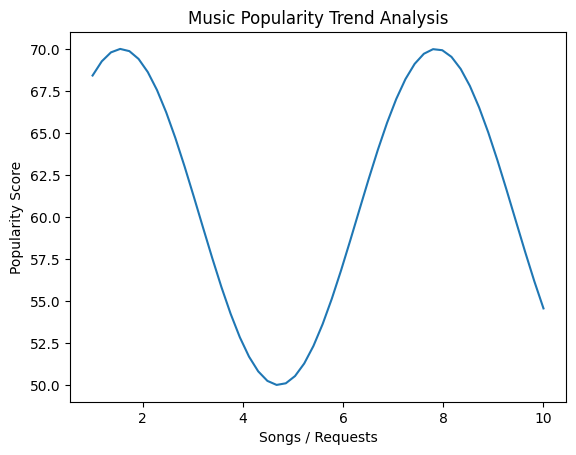

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(1, 10, 50)

y = np.sin(x) * 10 + 60

plt.figure()
plt.plot(x, y)
plt.title("Music Popularity Trend Analysis")
plt.xlabel("Songs / Requests")
plt.ylabel("Popularity Score")
plt.show()

Accuracy: 0.7


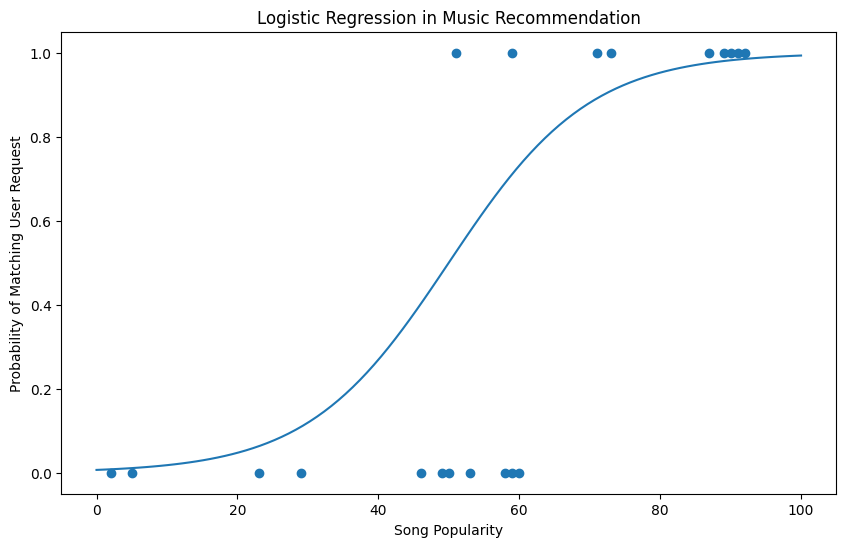

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# إنشاء بيانات تمثل شعبية الأغاني
np.random.seed(42)
popularity = np.random.randint(0, 100, 100)

# احتمال أن تكون الأغنية مناسبة لطلب المستخدم
music_prob = 1 / (1 + np.exp(-(popularity - 50)/10))

# تحديد النتيجة (مناسبة =1 ، غير مناسبة =0)
result = np.random.binomial(1, music_prob)

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    popularity.reshape(-1,1), result, test_size=0.2, random_state=42
)

# تدريب نموذج الانحدار اللوجستي
model = LogisticRegression()
model.fit(X_train, y_train)

# التنبؤ
y_pred = model.predict(X_test)

# حساب الدقة
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# رسم المنحنى
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test)

x_values = np.linspace(0,100,100)
y_proba = 1/(1+np.exp(-(x_values-50)/10))

plt.plot(x_values, y_proba)
plt.xlabel("Song Popularity")
plt.ylabel("Probability of Matching User Request")
plt.title("Logistic Regression in Music Recommendation")
plt.show()